[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/04-unsupervised/03_gaussian_mixtures_and_bic.ipynb)

# Two Definitions of a Cluster

**Session 18 · no homework grades this · the capstone often does**

DBSCAN and a Gaussian mixture disagree about what a cluster *is*, and the
disagreement is not a detail — it decides which shapes each one can find, what
happens to the points that belong to nothing, and whether "how many clusters?"
is even a question the method can answer.

- **DBSCAN:** a cluster is a dense region. Points in sparse space are noise.
- **Gaussian mixture:** a cluster is a distribution. Every point belongs to every
  cluster, with a probability.

This notebook runs both on data built to embarrass each of them in turn, and
ends with BIC — the only principled answer to "how many?" in this session.

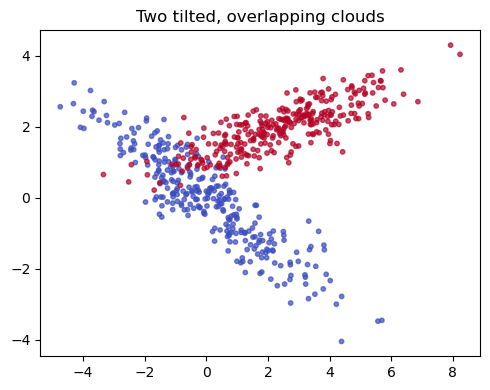

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(18)

def tilted(n, centre, angle, scale):
    base = rng.normal(size=(n, 2)) * scale
    c, s = np.cos(angle), np.sin(angle)
    return base @ np.array([[c, -s], [s, c]]) + centre

# Two elongated, tilted, overlapping clouds -- the shape k-means cannot represent
# and a full-covariance mixture can.
clouds = np.vstack([tilted(300, (0, 0), 0.6, (2.2, 0.45)),
                    tilted(300, (2.5, 2.0), -0.3, (2.0, 0.4))])
truth = np.r_[np.zeros(300, int), np.ones(300, int)]

plt.figure(figsize=(5, 4))
plt.scatter(*clouds.T, c=truth, s=10, cmap="coolwarm", alpha=.7)
plt.title("Two tilted, overlapping clouds"); plt.tight_layout(); plt.show()

## 1. What k-means can and cannot say

K-means models a cluster as a centroid, which means its decision boundary is a
straight line halfway between two centroids. On tilted, elongated clouds that is
the wrong shape, and no amount of restarting fixes it.

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture

km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(clouds)
gm = GaussianMixture(n_components=2, covariance_type="full", random_state=0).fit(clouds)

print(f"adjusted Rand index against the generating labels")
print(f"  k-means          {adjusted_rand_score(truth, km.labels_):.3f}")
print(f"  gaussian mixture {adjusted_rand_score(truth, gm.predict(clouds)):.3f}")

adjusted Rand index against the generating labels
  k-means          0.351
  gaussian mixture 0.798


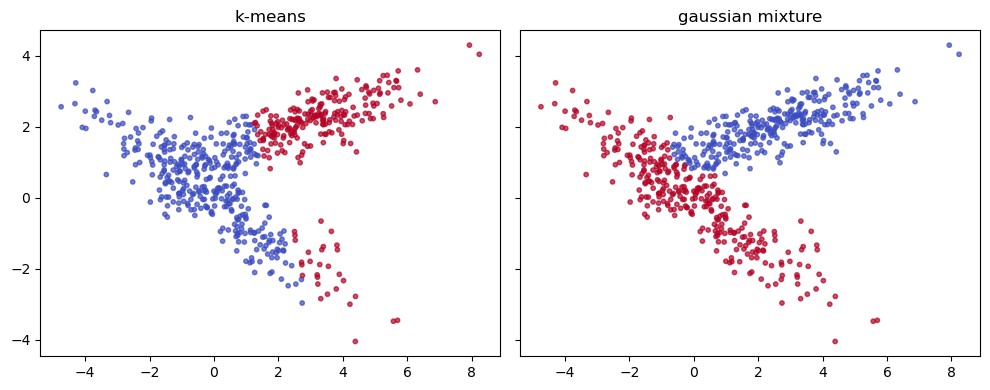

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, labels, name in ((axes[0], km.labels_, "k-means"),
                         (axes[1], gm.predict(clouds), "gaussian mixture")):
    ax.scatter(*clouds.T, c=labels, s=10, cmap="coolwarm", alpha=.7)
    ax.set_title(name)
plt.tight_layout(); plt.show()

## 2. Soft responsibilities: what a mixture knows that a label hides

`predict` gives you a label. `predict_proba` gives you the responsibility of each
component for each point, and the points in the overlap are exactly where the
distinction matters.

In [4]:
resp = gm.predict_proba(clouds)
confidence = resp.max(axis=1)

print(f"points assigned with >99% confidence : {(confidence > 0.99).sum():>4} of {len(clouds)}")
print(f"points in genuine doubt (55/45 or closer): {(confidence < 0.55).sum():>4}")

order = np.argsort(confidence)[:5]
print("\nthe five least certain points:")
print(pd.DataFrame({"x": clouds[order, 0].round(2), "y": clouds[order, 1].round(2),
                    "P(component 0)": resp[order, 0].round(3),
                    "P(component 1)": resp[order, 1].round(3)}).to_string(index=False))

points assigned with >99% confidence :  405 of 600
points in genuine doubt (55/45 or closer):    5

the five least certain points:
    x    y  P(component 0)  P(component 1)
-0.07 0.82           0.502           0.498
-0.29 0.89           0.492           0.508
-0.51 1.08           0.526           0.474
-0.27 0.93           0.531           0.469
-0.61 1.22           0.532           0.468


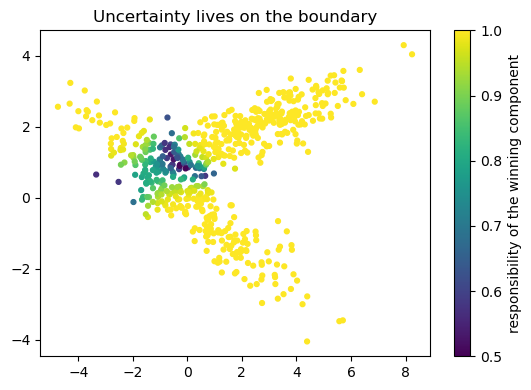

In [5]:
plt.figure(figsize=(5.5, 4))
sc = plt.scatter(*clouds.T, c=confidence, s=12, cmap="viridis", vmin=0.5, vmax=1.0)
plt.colorbar(sc, label="responsibility of the winning component")
plt.title("Uncertainty lives on the boundary"); plt.tight_layout(); plt.show()

A hard label throws that colour gradient away. When the downstream use is a
decision — flag this account, review this scan — the responsibility is the number
you want, and "the model was 51% sure" is a materially different statement from
"the model said cluster 1".

## 3. Covariance type is a capacity dial

`covariance_type` controls what shapes a component may take: `spherical` is a
circle, `diag` an axis-aligned ellipse, `full` any ellipse, `tied` one shared
shape for all components. Fewer parameters, less flexibility, less overfitting.

In [6]:
rows = []
for kind in ("spherical", "diag", "tied", "full"):
    m = GaussianMixture(n_components=2, covariance_type=kind, random_state=0).fit(clouds)
    rows.append({"covariance_type": kind,
                 "parameters": int(m._n_parameters()),
                 "log-likelihood/point": round(m.score(clouds), 4),
                 "BIC": round(m.bic(clouds), 1),
                 "ARI vs truth": round(adjusted_rand_score(truth, m.predict(clouds)), 3)})
print(pd.DataFrame(rows).to_string(index=False))

covariance_type  parameters  log-likelihood/point    BIC  ARI vs truth
      spherical           7               -3.9658 4803.7         0.245
           diag           9               -3.9135 4753.8         0.143
           tied           8               -3.8378 4656.5         0.453
           full          11               -3.3362 4073.8         0.798


`full` fits best here because the clouds really are tilted — the data was built
that way. On rounder data `spherical` would win on BIC despite fitting worse,
because it spends far fewer parameters to do it.

## 4. BIC: how many components?

BIC is the log-likelihood penalised by the number of parameters times log n.
Lower is better. It is a model-selection criterion, not a truth detector: it
tells you which of the models you tried explains the data most economically.

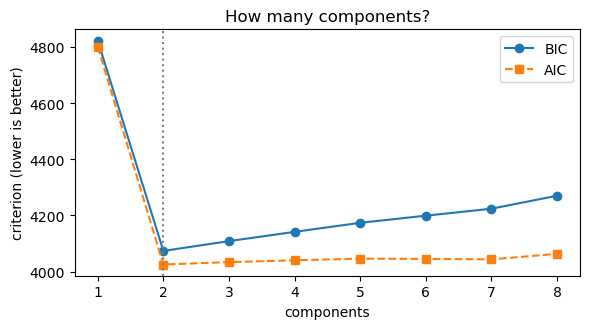

BIC minimum at k = 2
AIC minimum at k = 2


In [7]:
ks = range(1, 9)
bic = [GaussianMixture(n_components=k, covariance_type="full",
                       random_state=0).fit(clouds).bic(clouds) for k in ks]
aic = [GaussianMixture(n_components=k, covariance_type="full",
                       random_state=0).fit(clouds).aic(clouds) for k in ks]

plt.figure(figsize=(6, 3.4))
plt.plot(list(ks), bic, "o-", label="BIC")
plt.plot(list(ks), aic, "s--", label="AIC")
plt.axvline(list(ks)[int(np.argmin(bic))], color="grey", ls=":")
plt.xlabel("components"); plt.ylabel("criterion (lower is better)"); plt.legend()
plt.title("How many components?"); plt.tight_layout(); plt.show()

print("BIC minimum at k =", list(ks)[int(np.argmin(bic))])
print("AIC minimum at k =", list(ks)[int(np.argmin(aic))])

Both criteria pick the number of clouds the data was built from. They do not
always agree: AIC penalises parameters more lightly, so when the two differ it
is AIC that asks for more components. Reporting both costs one line and tells
the reader how sharp the choice was.

## 5. Does the answer survive a different seed?

EM is a local optimiser. `n_init` restarts it and keeps the best, and if the
chosen k moves when you change the seed then the curve is flatter than it
looks.

In [8]:
picks = []
for seed in range(8):
    scores = [GaussianMixture(n_components=k, covariance_type="full", n_init=3,
                              random_state=seed).fit(clouds).bic(clouds) for k in ks]
    picks.append(list(ks)[int(np.argmin(scores))])
print("k chosen by BIC across eight seeds:", picks)
print("stable:", len(set(picks)) == 1)

k chosen by BIC across eight seeds: [2, 2, 2, 2, 2, 2, 2, 2]
stable: True


## 6. Where DBSCAN wins, and where it does not

Density finds shapes no ellipse can: concentric rings defeat both k-means and a
mixture, and DBSCAN reads them without being told how many clusters to expect.
Its price is `eps`, and `eps` is not free.

In [9]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

moons, moon_truth = make_moons(n_samples=600, noise=0.06, random_state=0)

print(f"{'eps':>5} {'clusters':>9} {'noise points':>13} {'ARI vs truth':>13}")
for eps in (0.05, 0.10, 0.15, 0.20, 0.30, 0.50):
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(moons)
    n_clusters = len(set(labels) - {-1})
    print(f"{eps:>5.2f} {n_clusters:>9} {int((labels == -1).sum()):>13} "
          f"{adjusted_rand_score(moon_truth, labels):>13.3f}")

  eps  clusters  noise points  ARI vs truth
 0.05        36           216         0.026
 0.10         2             1         0.997
 0.15         2             0         1.000
 0.20         2             0         1.000
 0.30         2             0         1.000
 0.50         1             0         0.000


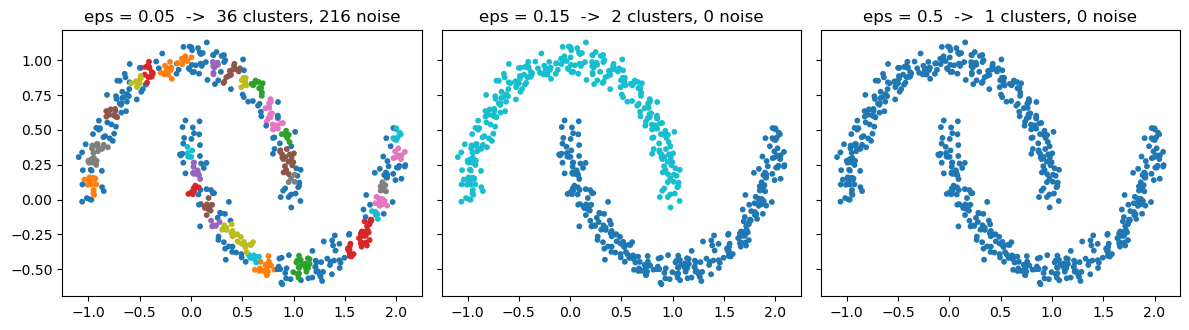

a two-component mixture on the same moons: ARI 0.494


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True, sharey=True)
for ax, eps in zip(axes, (0.05, 0.15, 0.50)):
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(moons)
    ax.scatter(*moons.T, c=labels, s=10, cmap="tab10")
    ax.set_title(f"eps = {eps}  ->  {len(set(labels) - {-1})} clusters, "
                 f"{int((labels == -1).sum())} noise")
plt.tight_layout(); plt.show()

gm_moons = GaussianMixture(n_components=2, covariance_type="full", random_state=0).fit(moons)
print(f"a two-component mixture on the same moons: ARI "
      f"{adjusted_rand_score(moon_truth, gm_moons.predict(moons)):.3f}")

Too small an `eps` and everything is noise; too large and everything is one
cluster. In between there is a range that recovers the moons almost perfectly —
and a mixture, which can only draw ellipses, cannot get there at any setting.

Report `eps`, `min_samples`, and the noise-point count together. A DBSCAN run
that labels 60% of the data as noise has not clustered anything.

## What to take from this

- The definition of "cluster" is a modelling choice: centroid, distribution, or
  dense region. Pick it by the shape you expect, and say which you picked.
- Responsibilities carry information a label discards. Use them when the
  downstream step is a decision.
- `covariance_type` is a capacity dial. BIC will happily prefer a simpler shape.
- BIC chooses among the models you tried; it does not discover truth. Check that
  its choice survives a change of seed.
- DBSCAN's `eps` is a real parameter with a real answer, and its noise count is
  part of the result.

## Where to go next

- **Reading, Session 18** — DBSCAN, mixtures, and clustering as exploratory
  analysis.
- **`01_reading_unsupervised_results.ipynb`** — the checks that stop an
  unsupervised result from becoming a claim.
- **The capstone** — if clustering appears in it, this notebook is the standard
  its results are held to.